#Aprendizagem de Máquina - Projeto da 1ª Unidade

Equipe: Alrykemes Cavalcanti, Breno Montenegro, Elton Alves

Base de Dados escolhida: Vídeo Game Sales

Tipo de Tarefa: Classificação

# Nossas Instruções.

1.     Carregar o conjunto de dados usando a biblioteca Pandas.
2.     Verificar e adotar a estratégia adequada para tratar possíveis dados ausentes no conjunto de dados.
3.    Realizar a análise exploratória de cada um dos atributos preditores do
conjunto de dados plotando os gráficos adequados, conforma nós
estudamos.
4. Verificar se existem "Outliers" usando as estratégias estudadas.
5.     Realizar a divisão adequada do conjunto de dados em dois
subconjuntos: treinamento e testes, realizando a estratificação quando
se tratar de problemas de classificação.
6.     Escolher pelo menos  três algoritmos de classificação ou regressão, a depender do problema
que se está resolvendo. (Para verificar os algoritmos disponíveis
verificar em: https://scikit-learn.org/stable/supervised_learning.html)
7.     Comparar o erro/acurácia dos modelos gerados.
8. Realizar otimização de Hiperparâmetros nos modelos escolhidos no passo 6
9.  Comparar o erro/acurácia dos modelos otimizados gerados.
10. Comparar o erro/acurácia obtidos nos passos 7 e 9 e discutir como a otimização melhorou o erro/acurácia dos modelos gerados

# 1. Importação de conjunto de dados utilizando Pandas.

In [1]:
# Importa a biblioteca pandas, usada para análise e manipulação de dados.
import pandas as pd

# Importa a biblioteca gdown, utilizada para baixar arquivos diretamente do Google Drive.
import gdown

# Define a URL de download do arquivo no Google Drive.
# Essa URL já está formatada com 'uc?export=download&id=' para permitir o download direto.
url = 'https://drive.google.com/uc?export=download&id=1K1jNjCPG5jY-uTuBYPV1nxlKU5sGaah3'

# Define o nome do arquivo de saída que será salvo localmente após o download.
output = 'vgsales.csv'

# Faz o download do arquivo da URL especificada e o salva com o nome definido na variável `output`.
# O terceiro argumento "False" indica que o progresso do download não será exibido.
gdown.download(url, output, False)

# Lê o arquivo CSV baixado e armazena o conteúdo em um DataFrame chamado `df`.
df = pd.read_csv(output)

# Exibe as primeiras 5 linhas do DataFrame para visualização inicial dos dados.
df.head()

Downloading...
From: https://drive.google.com/uc?export=download&id=1K1jNjCPG5jY-uTuBYPV1nxlKU5sGaah3
To: /content/vgsales.csv
100%|██████████| 1.36M/1.36M [00:00<00:00, 89.7MB/s]


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# 2. Tratamento de Dados do Conjunto.


- Verificamos a quantidade de dados ausentes e duplicados.
- Encontrando os seguintes resultados:
  - 307 linhas que contém dados ausentes.
  - Em colunas, obtivemos os seguintes dados ausentes:
    - Year: 271
    - Publisher: 58

- Dessa forma, por não impactar criticamente a análise do modelo, optamos por apagar os dados ausentes.

In [2]:
# Verifica se há valores ausentes (NaN) em cada linha.
print("Linhas que contém dados ausentes: ", df.isnull().any(axis=1).sum())

# Verifica a quantidade de valores ausentes em cada coluna do DataFrame.
print("Colunas que contém dados ausentes:\n", df.isnull().sum())

# Verifica quantas linhas duplicadas existem no DataFrame.
print("Linhas contendo dados duplicados: ", df.duplicated().sum())

# Remove todas as linhas que contêm ao menos um valor ausente (NaN) do DataFrame.
df = df.dropna()

# Exibe as novas dimensões (número de linhas e colunas) do DataFrame após a exclusão de linhas com dados ausentes.
print("✅ Depois da exclusão:", df.shape)

# Mostra novamente a contagem de valores ausentes por coluna, agora que as linhas com valores ausentes foram removidas.
# Espera-se que o resultado seja zero para todas as colunas.
print("\n🔍 Valores ausentes após remoção:\n", df.isnull().sum())

Linhas que contém dados ausentes:  307
Colunas que contém dados ausentes:
 Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Linhas contendo dados duplicados:  0
✅ Depois da exclusão: (16291, 11)

🔍 Valores ausentes após remoção:
 Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


# 3. Análise Exploratória com Gráficos

- Os gráficos abaixo foram criados analisando as seguintes situações:
  - Distribuição de plataformas (as mais vendidas)
  - Distribuição de gêneros dos jogos (os mais jogados)
  - Distribuição por ano de lançamento
  - Boxplot de vendas por região

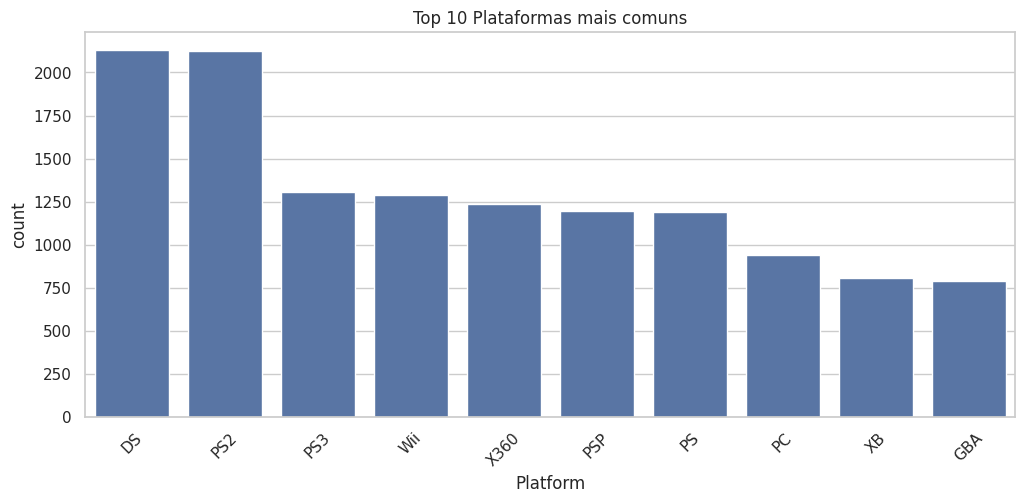


--------------------------------------------------------------------------------------------------------------------------------------------



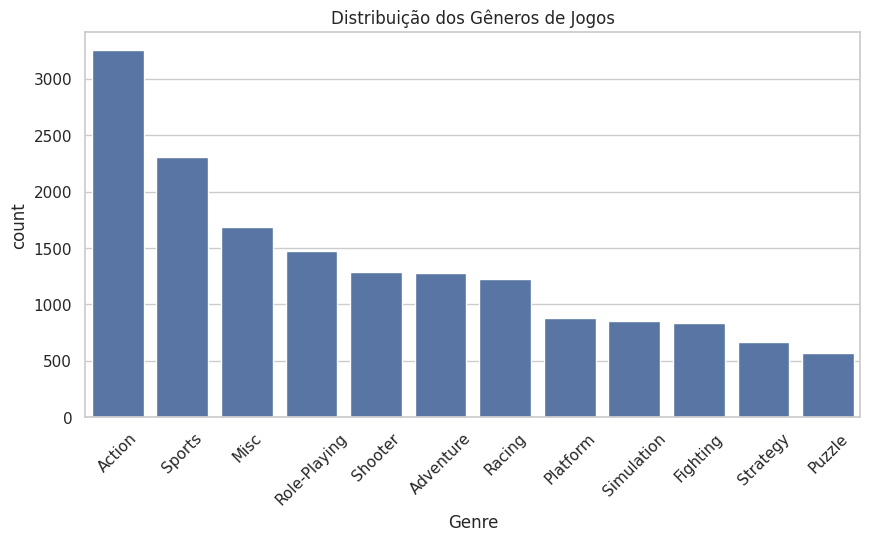


--------------------------------------------------------------------------------------------------------------------------------------------



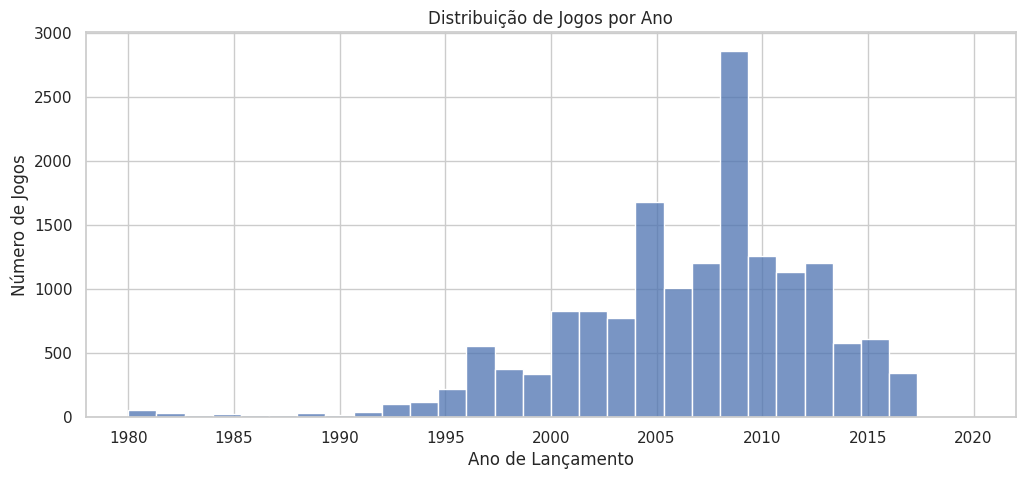


--------------------------------------------------------------------------------------------------------------------------------------------



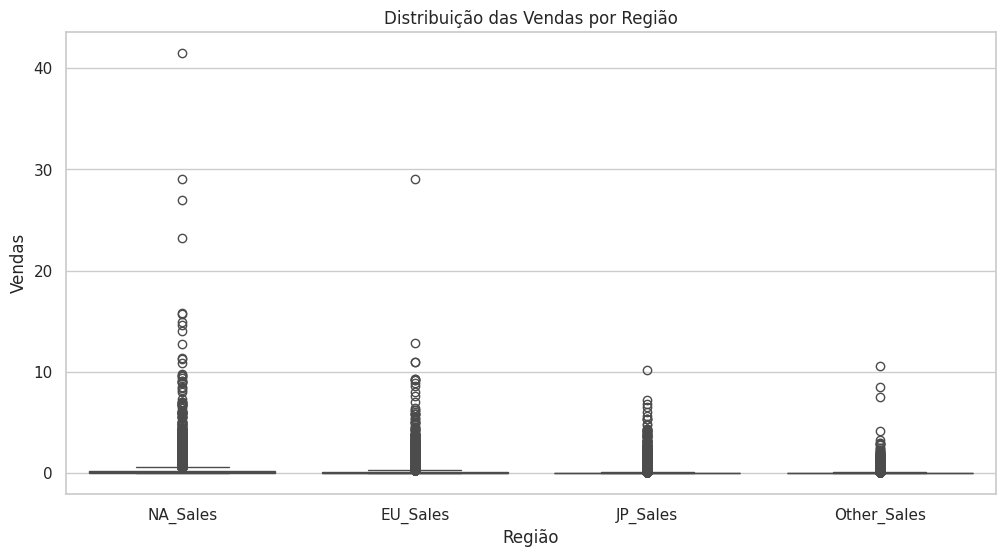

In [3]:
# Importa o matplotlib para visualizações gráficas.
import matplotlib.pyplot as plt

# Importa o seaborn, uma biblioteca de visualização baseada no matplotlib com estilo mais sofisticado.
import seaborn as sns

# Define o estilo visual dos gráficos do seaborn como "whitegrid" (fundo branco com grades).
sns.set(style="whitegrid")

# ------------------------- Gráfico 1: Top 10 Plataformas -------------------------

# Cria uma figura com tamanho 12x5 polegadas.
plt.figure(figsize=(12, 5))

# Cria um gráfico de contagem (barras) com os 10 principais valores da coluna 'Platform'.
# Garante que as plataformas mais frequentes apareçam primeiro.
sns.countplot(data=df, x='Platform', order=df['Platform'].value_counts().index[:10])

# Define o título do gráfico.
plt.title('Top 10 Plataformas mais comuns')

# Rotaciona os rótulos do eixo X em 45 graus para melhorar a leitura.
plt.xticks(rotation=45)

# Exibe o gráfico.
plt.show()

# Imprime uma linha separadora no console para organização visual.
print('\n' + '-'*140 + '\n')

# ------------------------- Gráfico 2: Distribuição de Gêneros -------------------------

# Cria uma figura com tamanho 10x5 polegadas.
plt.figure(figsize=(10, 5))

# Cria um gráfico de contagem para os gêneros de jogos, ordenando do mais comum para o menos comum.
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index)

# Define o título do gráfico.
plt.title('Distribuição dos Gêneros de Jogos')

# Rotaciona os rótulos do eixo X em 45 graus.
plt.xticks(rotation=45)

# Exibe o gráfico.
plt.show()

# Outra linha separadora para organização visual.
print('\n' + '-'*140 + '\n')

# ------------------------- Gráfico 3: Distribuição por Ano -------------------------

# Cria uma nova figura com tamanho 12x5 polegadas.
plt.figure(figsize=(12, 5))

# Cria um histograma da coluna 'Year', com 30 faixas (bins), sem a curva de densidade (kde=False).
sns.histplot(df['Year'], bins=30, kde=False)

# Define o título e os rótulos dos eixos X e Y.
plt.title('Distribuição de Jogos por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Jogos')

# Exibe o gráfico.
plt.show()

# Linha separadora no console.
print('\n' + '-'*140 + '\n')

# ------------------------- Gráfico 4: Vendas por Região (Boxplot) -------------------------

# Cria uma nova figura com tamanho 12x6 polegadas.
plt.figure(figsize=(12, 6))

# Define as colunas referentes às vendas por região.
sales_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Transforma o DataFrame de formato largo para longo com `melt`, criando colunas 'Região' e 'Vendas'.
# Isso é necessário para fazer um boxplot comparativo entre as regiões.
df_melted = df[sales_columns].melt(var_name='Região', value_name='Vendas')

# Cria um boxplot que mostra a distribuição das vendas em cada região.
sns.boxplot(x='Região', y='Vendas', data=df_melted)

# Define o título do gráfico.
plt.title('Distribuição das Vendas por Região')

# Exibe o gráfico.
plt.show()

# 4. Análise de Outliers

  - Com base na análise dos gráficos boxplots, foi possível observar a distribuição das vendas por região. A região da América do Norte apresentou a maior concentração de outliers, ou seja, valores que se distanciam significativamente do padrão geral dos dados. Esses outliers representam títulos de jogos com volumes de vendas excepcionalmente altos, que fogem à tendência da maioria dos jogos analisados.

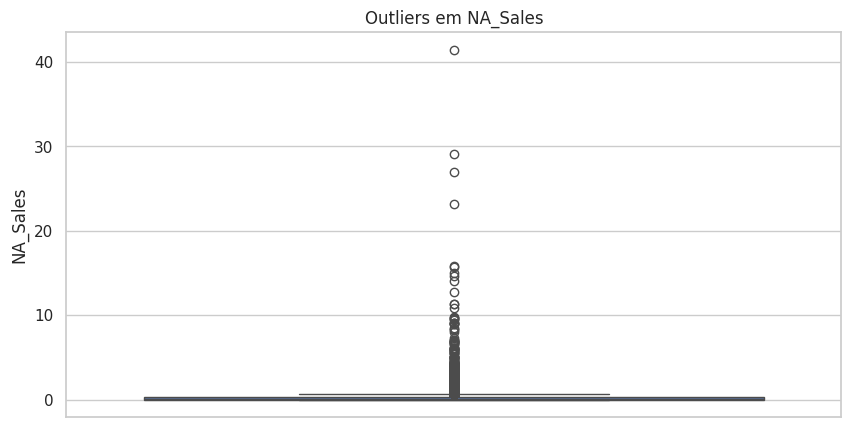


--------------------------------------------------------------------------------------------------------------------------------------------



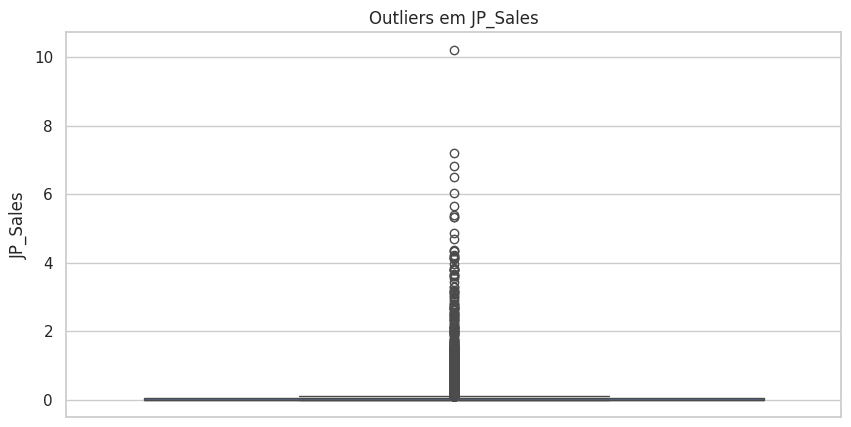


--------------------------------------------------------------------------------------------------------------------------------------------



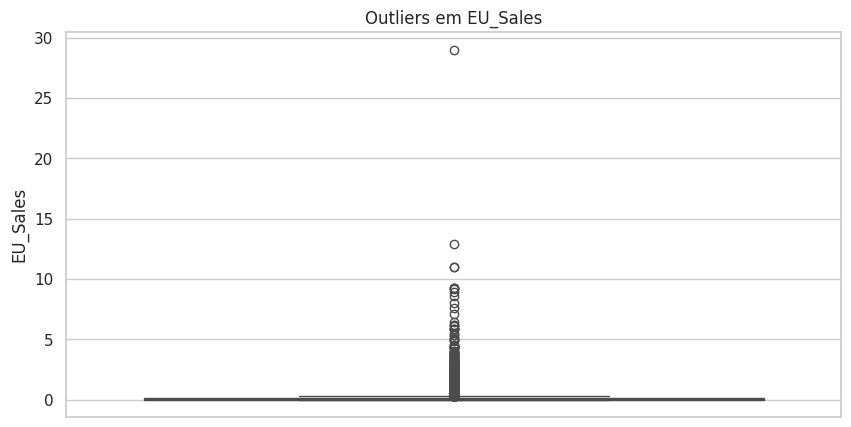


--------------------------------------------------------------------------------------------------------------------------------------------



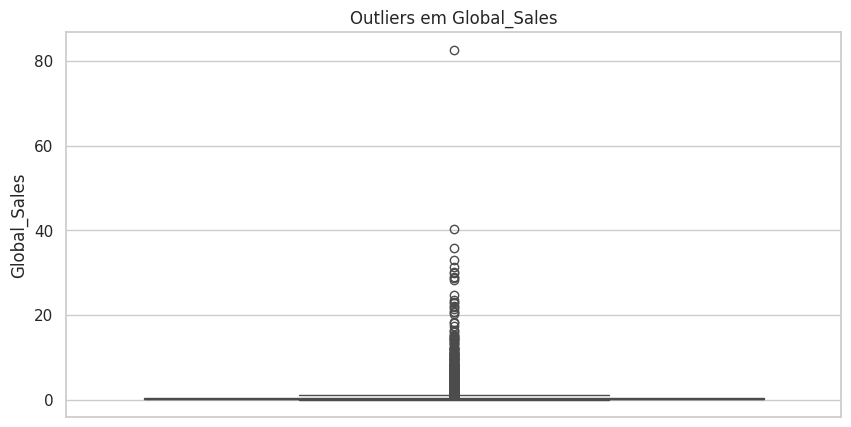

In [4]:
# Importa a biblioteca matplotlib para visualizações.
import matplotlib.pyplot as plt

# Importa a biblioteca seaborn, que fornece gráficos estatísticos com visual mais moderno.
import seaborn as sns

# ------------------------- Boxplot: NA_Sales -------------------------

# Cria uma nova figura com tamanho 10x5 polegadas.
plt.figure(figsize=(10, 5))

# Cria um boxplot para a coluna 'NA_Sales' (vendas na América do Norte).
# Um boxplot mostra a mediana, quartis e possíveis outliers.
sns.boxplot(data=df, y='NA_Sales')

# Define o título do gráfico.
plt.title('Outliers em NA_Sales')

# Exibe o gráfico na tela.
plt.show()

# Imprime uma linha separadora no terminal para melhor organização visual.
print('\n' + '-'*140 + '\n')

# ------------------------- Boxplot: JP_Sales -------------------------

# Cria uma nova figura com tamanho 10x5 polegadas.
plt.figure(figsize=(10, 5))

# Cria um boxplot para a coluna 'JP_Sales' (vendas no Japão).
sns.boxplot(data=df, y='JP_Sales')

# Define o título do gráfico.
plt.title('Outliers em JP_Sales')

# Exibe o gráfico.
plt.show()

# Linha separadora no terminal.
print('\n' + '-'*140 + '\n')

# ------------------------- Boxplot: EU_Sales -------------------------

# Importa bibliotecas, caso ainda não tenha importado
import matplotlib.pyplot as plt
import seaborn as sns

# Cria uma nova figura com tamanho 10x5 polegadas.
plt.figure(figsize=(10, 5))

# Cria o boxplot para a coluna 'EU_Sales' (vendas na Europa).
sns.boxplot(data=df, y='EU_Sales')

# Define o título do gráfico.
plt.title('Outliers em EU_Sales')

# Exibe o gráfico na tela.
plt.show()

print('\n' + '-'*140 + '\n')

# ------------------------- Boxplot: Global_Sales -------------------------

# Cria uma nova figura com tamanho 10x5 polegadas.
plt.figure(figsize=(10, 5))

# Cria um boxplot para a coluna 'Global_Sales' (vendas globais).
sns.boxplot(data=df, y='Global_Sales')

# Define o título do gráfico.
plt.title('Outliers em Global_Sales')

# Exibe o gráfico.
plt.show()

- Dessa forma, optamos por apagar os outliers para que não impactam nossa base de Dados.

In [5]:
# Importa a biblioteca pandas para manipulação de dados tabulares.
import pandas as pd

# Define a lista de colunas de vendas que serão analisadas para remoção de outliers.
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# ---------------------- Função: get_iqr_limits ----------------------
# Esta função calcula os limites inferior e superior com base no Intervalo Interquartil
# para detectar outliers em uma coluna numérica.

def get_iqr_limits(df, col):
    # Primeiro quartil (25% dos dados abaixo deste valor)
    Q1 = df[col].quantile(0.25)
    # Terceiro quartil (75% dos dados abaixo deste valor)
    Q3 = df[col].quantile(0.75)
    # Intervalo interquartil (IQR) = Q3 - Q1
    IQR = Q3 - Q1
    # Limite inferior: valores abaixo disso são considerados outliers
    lim_inf = Q1 - 1.5 * IQR
    # Limite superior: valores acima disso são considerados outliers
    lim_sup = Q3 + 1.5 * IQR
    # Retorna os limites calculados
    return lim_inf, lim_sup

# ---------------------- Função: remover_outliers ----------------------
# Esta função aplica a remoção de outliers com base no IQR para múltiplas colunas.

def remover_outliers(df, cols):
    # Cria uma máscara booleana inicialmente verdadeira para todas as linhas.
    mask = pd.Series(True, index=df.index)
    # Para cada coluna fornecida...
    for col in cols:
        # Obtém os limites inferior e superior para a coluna atual.
        lim_inf, lim_sup = get_iqr_limits(df, col)
        # Atualiza a máscara para manter apenas os valores dentro dos limites definidos.
        mask &= df[col].between(lim_inf, lim_sup)
    # Retorna o DataFrame somente com as linhas que passaram pela máscara (sem outliers).
    return df[mask]

# Aplica a função de remoção de outliers ao DataFrame original, considerando as colunas de vendas.
df_sem_outliers = remover_outliers(df, sales_cols)

# Exibe o número de linhas e colunas do DataFrame original.
print("Tamanho original:", df.shape)

# Exibe o número de linhas e colunas após a remoção de outliers.
print("Tamanho após remoção de outliers:", df_sem_outliers.shape)


Tamanho original: (16291, 11)
Tamanho após remoção de outliers: (11767, 11)


- Gráficos sem outliers

/tmp/ipython-input-6-4272821779.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


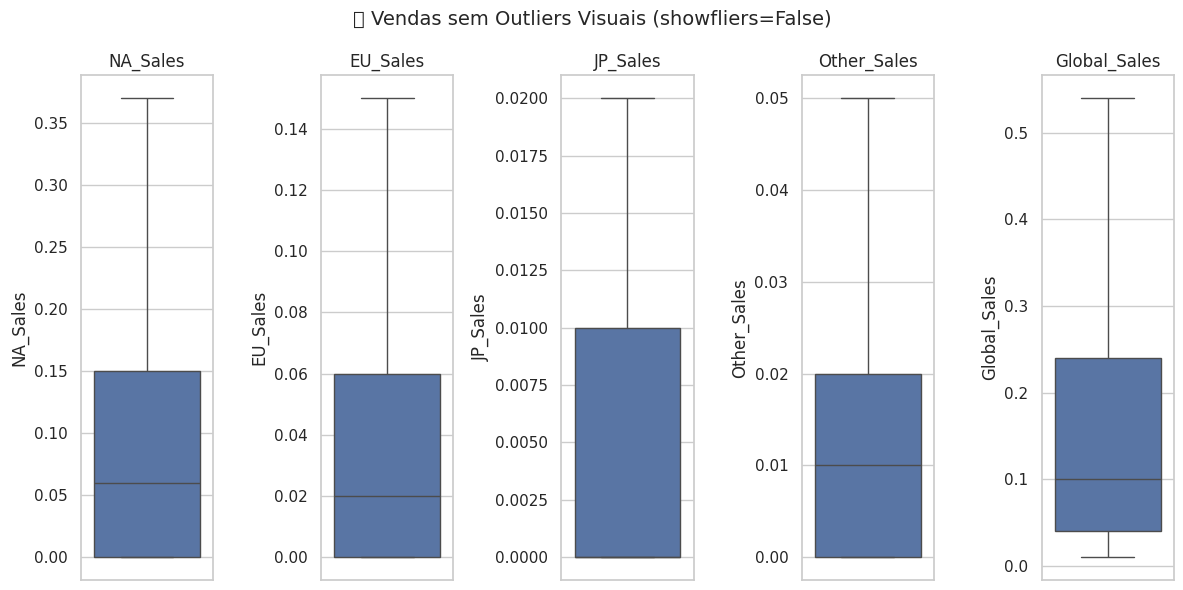

In [6]:
# Importa o seaborn para visualização estatística dos dados.
import seaborn as sns

# Importa o matplotlib para criação de gráficos.
import matplotlib.pyplot as plt

# Cria uma nova figura com tamanho 12x6 polegadas.
plt.figure(figsize=(12, 6))

# ---------------------- Laço para plotar múltiplos boxplots ----------------------

# Percorre cada coluna de vendas na lista sales_cols com seu índice correspondente.
for i, col in enumerate(sales_cols):
    # Cria um subplot (1 linha, 5 colunas, posição i+1).
    plt.subplot(1, 5, i+1)

    # Cria um boxplot para a coluna atual do DataFrame `df_sem_outliers`.
    # O parâmetro `showfliers=False` oculta os outliers visuais do gráfico.
    sns.boxplot(data=df_sem_outliers, y=col, showfliers=False)

    # Define o título do subplot com o nome da coluna.
    plt.title(col)

# Define um título geral para a figura inteira.
plt.suptitle('📊 Vendas sem Outliers Visuais (showfliers=False)', fontsize=14)

# Ajusta automaticamente o espaçamento entre os subplots para evitar sobreposição.
plt.tight_layout()

# Exibe todos os gráficos.
plt.show()

#5. Divisão para Treinamento e Testes

In [7]:
# Importa a função train_test_split do scikit-learn, usada para dividir os dados em conjuntos de treino e teste.
from sklearn.model_selection import train_test_split

# Cria a matriz de atributos (X) removendo a coluna 'Genre', que é a variável alvo.
X = df_sem_outliers.drop(columns=['Genre'])

# Cria o vetor de rótulos (y), que contém apenas a coluna 'Genre', ou seja, o que queremos prever.
y = df_sem_outliers['Genre']

# Divide os dados em conjunto de treino (80%) e teste (20%).
# - test_size=0.2: 20% dos dados vão para o conjunto de teste.
# - random_state=42: garante reprodutibilidade da divisão.
# - stratify=y: garante que a distribuição das classes (gêneros) em y seja proporcional nos conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Exibe o número total de registros no DataFrame após remoção de outliers.
print("Tamanho total:", len(df_sem_outliers))

# Exibe a quantidade de registros no conjunto de treinamento.
print("Treinamento:", len(X_train))

# Exibe a quantidade de registros no conjunto de teste.
print("Teste:", len(X_test))

Tamanho total: 11767
Treinamento: 9413
Teste: 2354


# 6. Escolha do problema e modelos.

- Problema: Classificação
  - Prever a melhor região para vender o jogo de acordo com seu gênero e plataforma, com o intuito de aumentar a quantidade de vendas.

  -  Dessa forma, será possível entender o comportamento do mercado em diferentes regiões, analisando não apenas o gênero que mais faz sucesso, mas também as plataformas.

- Com isso Optamos por agrupar as plataformas generalizando elas por fabricante.

In [8]:
!pip install mlflow pyngrok

from sklearn.preprocessing import LabelEncoder

# Função para agrupar plataformas por fabricantes/tipo
def agrupar_plataforma(p):
    if p in ['PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV']:
        return 'PlayStation'
    elif p in ['X360', 'XOne', 'XB']:
        return 'Xbox'
    elif p in ['Wii', 'WiiU', 'GC', 'N64', 'NS']:
        return 'Nintendo Console'
    elif p in ['DS', '3DS', 'GBA', 'GB']:
        return 'Nintendo Portátil'
    else:
        return 'PC/Outros'

# Copia dataframe sem outliers
df = df_sem_outliers.copy()

# executa função de agrupamento de plataformas e coloca na coluna PlataformaAgrupada criada no dataframe
df['Plataform'] = df['Platform'].apply(agrupar_plataforma)

# Criar coluna com a região que teve mais vendas
def regiao_mais_forte(row):
    regioes = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
    return max(regioes, key=lambda x: row[x])

df['Top_Region'] = df.apply(regiao_mais_forte, axis=1)

# Remover colunas desnecessárias
df = df.drop(columns=['Name', 'Publisher', 'Global_Sales',
                            'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

# Remover linhas com valores ausentes
df = df.dropna()

# Codificar variáveis categóricas
le_genre = LabelEncoder()
df['Genre'] = le_genre.fit_transform(df['Genre'])

le_platform = LabelEncoder()
df['Platform'] = le_platform.fit_transform(df['Platform'])

le_top_region = LabelEncoder()
df['Top_Region_Encoded'] = le_top_region.fit_transform(df['Top_Region'])


# Selecionar apenas Platform e Genre como preditores
X = df[['Platform', 'Genre']]
y = df['Top_Region']
y_encoded = df['Top_Region_Encoded']

# Divisão dos dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.2/676.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 13.7 MB/s eta 0:00:00


# 6.1 Modelo n° 1: Random Forest


In [18]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

with mlflow.start_run(run_name="RandomForest"):
    # Modelo Random Forest com hiperparâmetros definidos
    clf_model = RandomForestClassifier(
        n_estimators=5,
        max_depth=3,
        min_samples_split=15,
        min_samples_leaf=6,
        random_state=42
    )

    # Treinamento
    clf_model.fit(X_train, y_train)

    # Previsões
    y_pred = clf_model.predict(X_test)

    # Avaliação
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Logging no MLflow
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 5)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("min_samples_split", 15)
    mlflow.log_param("min_samples_leaf", 6)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(clf_model, "modelo_random_forest")

    # Saída
    print("🌲 Acurácia:", acc)
    print("\n📋 Relatório de Classificação:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025/07/21 16:17:41 WARNING mlflow.models.model: 

🌲 Acurácia: 0.7009345794392523

📋 Relatório de Classificação:

              precision    recall  f1-score   support

    EU_Sales       0.00      0.00      0.00       313
    JP_Sales       0.81      0.18      0.29       455
    NA_Sales       0.70      0.99      0.82      1585
 Other_Sales       0.00      0.00      0.00         1

    accuracy                           0.70      2354
   macro avg       0.38      0.29      0.28      2354
weighted avg       0.63      0.70      0.61      2354



- O modelo não conseguiu prever nenhum caso corretamente da classe Other_Sales, porém isso ocorreu porque a base de dados só possui 1 exemplo.

- Portanto, Other_Sales será removida futuramente.

# 6.2 Modelo n° 2: Gradient Boosting

In [19]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

with mlflow.start_run(run_name="GradientBoosting"):
    # Dicionário de pesos para balanceamento
    class_weight_person = {
        'NA_Sales': 1.0,
        'EU_Sales': 3.2,
        'JP_Sales': 2.8,
    }

    # Cálculo dos pesos de amostra
    sample_weights = compute_sample_weight(class_weight=class_weight_person, y=y_train)

    # Criação e treino do modelo
    gb_model = GradientBoostingClassifier(random_state=42)
    gb_model.fit(X_train, y_train, sample_weight=sample_weights)

    # Previsões
    y_pred = gb_model.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Logs no MLflow
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(gb_model, "modelo_gradient_boosting")

    print("🌟 Resultados do Gradient Boosting Classifier:")
    print("Acurácia:", acc)
    print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025/07/21 16:17:45 WARNING mlflow.models.model: 

🌟 Resultados do Gradient Boosting Classifier:
Acurácia: 0.7387425658453696

Relatório de Classificação:
               precision    recall  f1-score   support

    EU_Sales       0.58      0.62      0.60       313
    JP_Sales       0.52      0.71      0.60       455
    NA_Sales       0.87      0.77      0.82      1585
 Other_Sales       0.00      0.00      0.00         1

    accuracy                           0.74      2354
   macro avg       0.49      0.53      0.51      2354
weighted avg       0.77      0.74      0.75      2354



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Este modelo também não conseguiu prever nenhum caso corretamente da classe Other_Sales, porém o problema já foi discutido anteriormente.

- Além disso, já é possível perceber uma melhora em relação ao Modelo Random Forest com relação ao alcance da acurácia.

# 6.3 Modelo n° 3: k-Nearest Neighbors

In [20]:
import mlflow
import mlflow.sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

with mlflow.start_run(run_name="KNN"):
    # Instancia e treina o modelo
    knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
    knn_model.fit(X_train, y_train)

    # Faz previsões
    y_pred_knn = knn_model.predict(X_test)

    # Calcula métricas
    acc = accuracy_score(y_test, y_pred_knn)
    report = classification_report(y_test, y_pred_knn, output_dict=True)

    # Loga parâmetros e métricas no MLflow
    mlflow.log_param("n_neighbors", 5)
    mlflow.log_param("weights", "distance")
    mlflow.log_metric("accuracy", acc)

    # Loga o modelo treinado
    mlflow.sklearn.log_model(knn_model, "modelo_knn")

    print("🔍 Resultados do K-Nearest Neighbors Classifier:")
    print("Acurácia:", acc)
    print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_knn))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025/07/21 16:17:48 WARNING mlflow.models.model: 

🔍 Resultados do K-Nearest Neighbors Classifier:
Acurácia: 0.7391673746813934

Relatório de Classificação:
               precision    recall  f1-score   support

    EU_Sales       0.61      0.45      0.52       313
    JP_Sales       0.56      0.54      0.55       455
    NA_Sales       0.81      0.85      0.83      1585
 Other_Sales       0.00      0.00      0.00         1

    accuracy                           0.74      2354
   macro avg       0.49      0.46      0.47      2354
weighted avg       0.73      0.74      0.73      2354



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 6.4 Modelo n° 4: Support Vector Machine

In [21]:
import mlflow
import mlflow.sklearn
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Inicia uma run no MLflow
with mlflow.start_run(run_name="SVM_Model"):

    # Instancia o modelo SVM
    svm_model = SVC(kernel='linear', C=1.0, random_state=42)

    # Treina o modelo
    svm_model.fit(X_train, y_train)

    # Faz previsões
    y_pred = svm_model.predict(X_test)

    # Calcula a acurácia
    acc = accuracy_score(y_test, y_pred)
    print("Acurácia do SVM:", acc)

    # Loga os parâmetros e a métrica no MLflow
    mlflow.log_param("kernel", "linear")
    mlflow.log_param("C", 1.0)
    mlflow.log_metric("accuracy", acc)

    # Loga o modelo treinado
    mlflow.sklearn.log_model(svm_model, "svm_model")

2025/07/21 16:17:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Acurácia do SVM: 0.673322005097706


2025/07/21 16:17:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# 6.5 Modelo nº 5: MultiLayer Perceptron

2025/07/21 17:34:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Acurácia: 0.7765505522514868

Relatório de Classificação:
              precision    recall  f1-score   support

    EU_Sales       0.79      0.41      0.54       291
    JP_Sales       0.66      0.44      0.53       432
    NA_Sales       0.79      0.93      0.86      1629
 Other_Sales       0.00      0.00      0.00         2

    accuracy                           0.78      2354
   macro avg       0.56      0.44      0.48      2354
weighted avg       0.77      0.78      0.76      2354



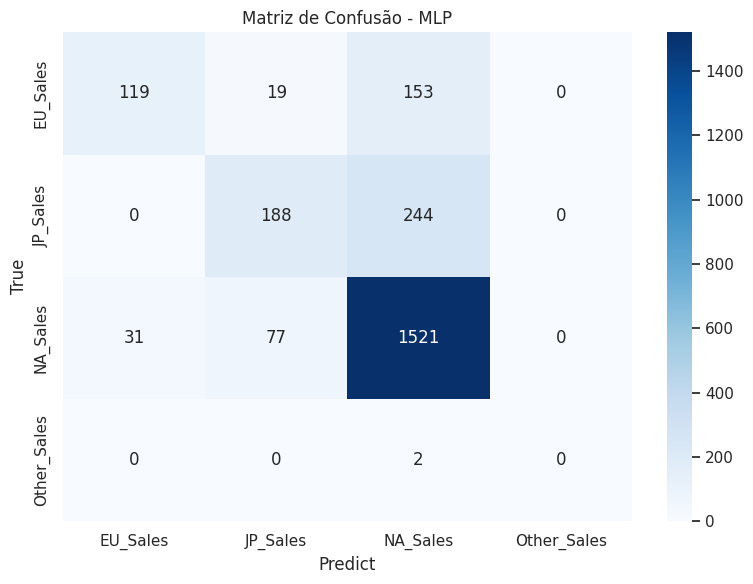

In [9]:
import pandas as pd
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# Normalizar as variáveis (importante para MLP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir em treino e teste
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Parametros do modelo
hidden_layers = (64, 32)
activation = 'relu'
max_iter = 500
random_state = 42

# Inicia uma run no MLflow
with mlflow.start_run(run_name="MLP_Model"):

  mlp_model = MLPClassifier(hidden_layer_sizes=hidden_layers, activation=activation, max_iter=max_iter, random_state=random_state)

  mlp_model.fit(X_train_mlp, y_train_mlp)

  y_pred_mlp = mlp_model.predict(X_test_mlp)

  acc = accuracy_score(y_test_mlp, y_pred_mlp)
  f1 = f1_score(y_test_mlp, y_pred_mlp, average='weighted')

  # Log de parâmetros
  mlflow.log_param("hidden_layer_sizes", hidden_layers)
  mlflow.log_param("activation", activation)
  mlflow.log_param("max_iter", max_iter)
  mlflow.log_param("random_state", random_state)

  # Log de métricas
  mlflow.log_metric("accuracy", acc)
  mlflow.log_metric("f1_score_weighted", f1)

  # Log do modelo com exemplo de entrada
  input_example = np.array([[0, 1]])  # Exemplo: Platform 0, Genre 1
  mlflow.sklearn.log_model(mlp_model, "MLP_model", input_example=input_example)

  # Gera e salva a matriz de confusão
  cm = confusion_matrix(y_test_mlp, y_pred_mlp)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=le_top_region.classes_,
              yticklabels=le_top_region.classes_)
  plt.xlabel("Predict")
  plt.ylabel("True")
  plt.title("Matriz de Confusão - MLP")

  # Salva localmente e faz upload para o MLflow
  cm_path = "confusion_matrix.png"
  plt.tight_layout()
  plt.savefig(cm_path)
  mlflow.log_artifact(cm_path)

  # Imprime resumo no console
  print("Acurácia:", acc)
  print("\nRelatório de Classificação:")
  print(classification_report(y_test_mlp, y_pred_mlp, target_names=le_top_region.classes_, zero_division=0))

# 7. Comparação dos Modelos

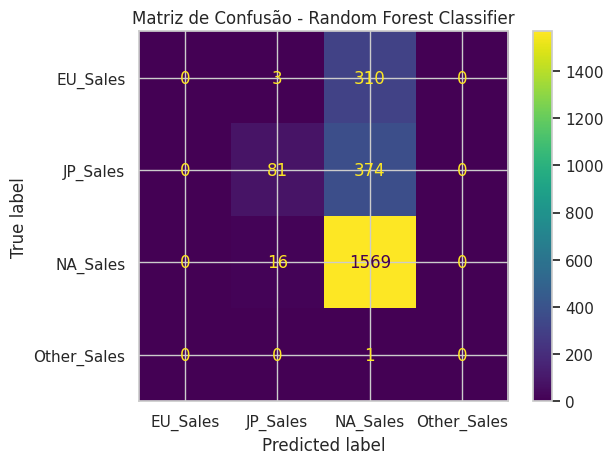

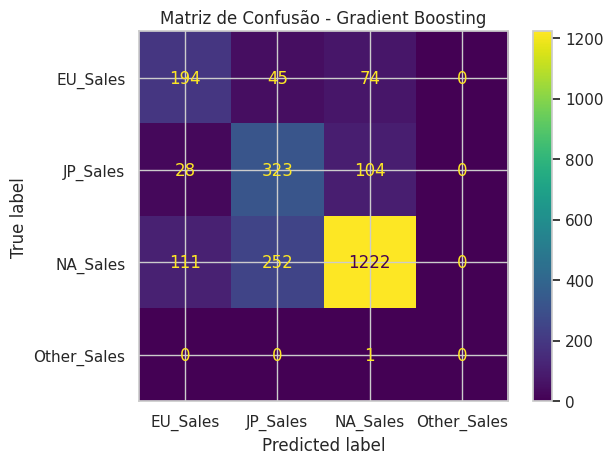

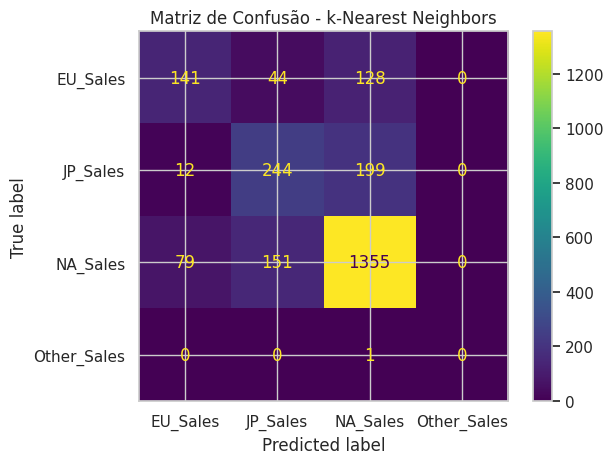

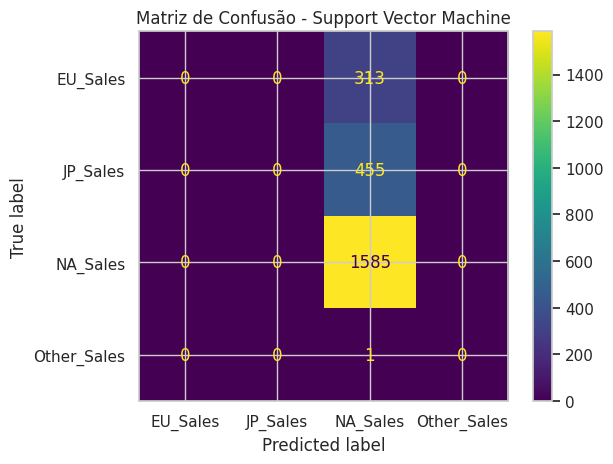

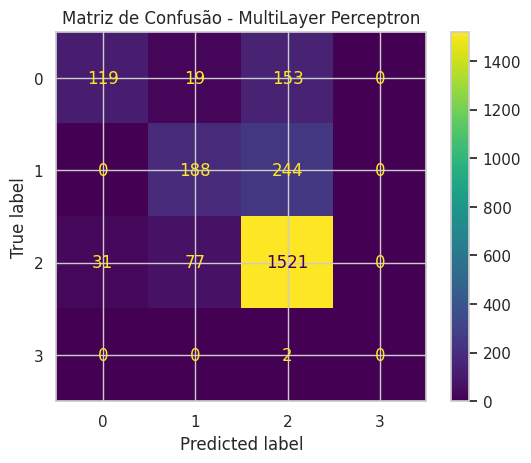

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Exibir a matriz de confusão CLF
disp = ConfusionMatrixDisplay.from_estimator(
    clf_model, X_test, y_test,
    cmap='viridis',  # ou qualquer outro colormap
    display_labels=clf_model.classes_
)

plt.title("Matriz de Confusão - Random Forest Classifier")
plt.show()

# Exibir a matriz de confusão GB
disp = ConfusionMatrixDisplay.from_estimator(
    gb_model, X_test, y_test,
    cmap='viridis',  # ou qualquer outro colormap
    display_labels=gb_model.classes_
)

plt.title("Matriz de Confusão - Gradient Boosting")
plt.show()

# Exibir a matriz de confusão k-Nearest Neighbors
disp = ConfusionMatrixDisplay.from_estimator(
    knn_model, X_test, y_test,
    cmap='viridis',  # ou qualquer outro colormap
    display_labels=knn_model.classes_
)

plt.title("Matriz de Confusão - k-Nearest Neighbors")
plt.show()

# Exibir a matriz de confusão Support Vector Machine
disp = ConfusionMatrixDisplay.from_estimator(
    svm_model, X_test, y_test,
    cmap='viridis',  # ou qualquer outro colormap
    display_labels=svm_model.classes_
)

plt.title("Matriz de Confusão - Support Vector Machine")
plt.show()

# Exibir a matriz de confusão Multilayer Perceptron
disp = ConfusionMatrixDisplay.from_estimator(
    mlp_model, X_test_mlp, y_test_mlp,
    cmap='viridis',  # ou qualquer outro colormap
    display_labels=mlp_model.classes_
)

plt.title("Matriz de Confusão - MultiLayer Perceptron")
plt.show()

- Random Forest parece o mais preciso para NA Sales, mas menos equilibrado nas outras classes.
- Gradient Boosting oferece um equilíbrio melhor entre classes, embora com mais erros gerais.
- k-NN fica no meio-termo, com bom desempenho em NA Sales e distribuição razoável de erros.

# 8. Otimização de Hiperparâmetros.

- Decidimos Retirar a coluna Other_Sales por ter apenas 1 exemplo de venda, porque causava um esforço para o modelo aprender, porém não era possível em razão do único dado disponível.

In [10]:
# Remover a classe 'Other_Sales' (pouco representativa e atrapalha)
df = df[df['Top_Region'] != 'Other_Sales']

# Tratar a coluna 'Year'
df.loc[:, 'Year'] = pd.to_numeric(df['Year'], errors='coerce')

df = df.dropna(subset=['Year'])

# Remover valores ausentes restantes
df = df.dropna()

# Definir variáveis preditoras e alvo
X = df[['Platform', 'Genre', 'Year']]
y = df['Top_Region']
y_encoded = df['Top_Region_Encoded']

# Dividir conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 8.1 Modelo Random Forest

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [None, 'sqrt']
}

mlflow.set_experiment("GridSearch Random Forest")

with mlflow.start_run(run_name="RandomForest GridSearch"):

    clf = RandomForestClassifier(random_state=42)

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=2,
        scoring='accuracy'
    )

    grid_search.fit(X_train, y_train)

    best_clf = grid_search.best_estimator_

    y_pred = best_clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Log dos melhores hiperparâmetros
    for param, valor in grid_search.best_params_.items():
        mlflow.log_param(param, valor)

    # Log das métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision_weighted", report["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report["weighted avg"]["f1-score"])

    # Log do modelo
    mlflow.sklearn.log_model(best_clf, "random_forest_gridsearch_model")

    print("\n🔍 Melhores hiperparâmetros encontrados:")
    print(grid_search.best_params_)

    print("\n🔍 Acurácia após otimização:", acc)
    print("\n📋 Relatório de Classificação:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

2025/07/19 22:26:12 INFO mlflow.tracking.fluent: Experiment with name 'GridSearch Random Forest' does not exist. Creating a new experiment.


Fitting 5 folds for each of 72 candidates, totalling 360 fits


2025/07/19 22:31:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:31:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🔍 Melhores hiperparâmetros encontrados:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🔍 Acurácia após otimização: 0.8032299192520187

📋 Relatório de Classificação:

              precision    recall  f1-score   support

    EU_Sales       0.73      0.53      0.61       313
    JP_Sales       0.73      0.52      0.61       455
    NA_Sales       0.83      0.94      0.88      1585

    accuracy                           0.80      2353
   macro avg       0.76      0.66      0.70      2353
weighted avg       0.79      0.80      0.79      2353



- 🔍 Melhores hiperparâmetros encontrados para o Random Forest:
  - max_depth: 10
  - max_features: None
  - min_samples_leaf: 2
  - min_samples_split: 2
  - n_estimators: 200

- 🔍 Acurácia anterior (sem otimização): 0.70%
- 🔍 Acurácia após otimização: 0.80%

# Modelo Random Forest Classifier com melhores hiperparâmetros

2025/07/19 22:31:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:31:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🔍 Acurácia: 0.8002549936251594

📋 Relatório de Classificação:
               precision    recall  f1-score   support

    EU_Sales       0.74      0.51      0.61       313
    JP_Sales       0.75      0.49      0.59       455
    NA_Sales       0.82      0.95      0.88      1585

    accuracy                           0.80      2353
   macro avg       0.77      0.65      0.69      2353
weighted avg       0.79      0.80      0.79      2353



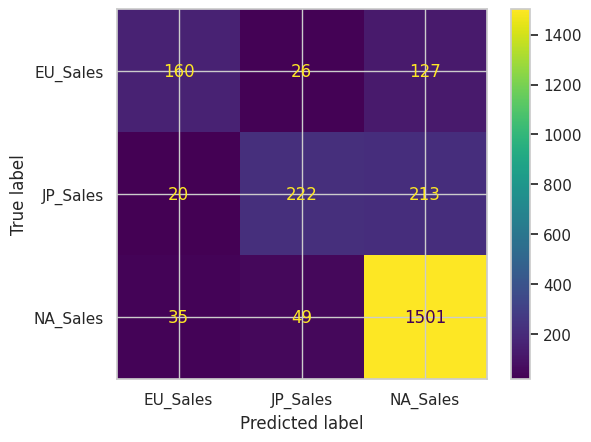

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

with mlflow.start_run(run_name="Random Forest Classifier"):
    # Hiperparâmetros
    n_estimators = 200
    max_depth = 10
    min_samples_split = 2
    min_samples_leaf = 2
    random_state = 42

    # Modelo
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )

    # Treinamento
    clf.fit(X_train, y_train)

    # Predição
    y_pred = clf.predict(X_test)

    # Avaliação
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

    # Métricas
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("min_samples_leaf", min_samples_leaf)
    mlflow.log_param("random_state", random_state)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("cv_accuracy_mean", scores.mean())

    # Modelo
    mlflow.sklearn.log_model(clf, "random_forest_model")

    # Prints opcionais
    print("🔍 Acurácia:", acc)
    print("\n📋 Relatório de Classificação:\n", classification_report(y_test, y_pred, zero_division=0))
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

# 8.2 Modelo Gradient Boosting.

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

class_weight_person = {
    'NA_Sales': 1.0,
    'EU_Sales': 3.2,
    'JP_Sales': 2.8,
}

# Pesos para balanceamento
sample_weights = compute_sample_weight(class_weight=class_weight_person, y=y_train)

param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', None]
}

mlflow.set_experiment("GridSearch Gradient Boosting")

with mlflow.start_run(run_name="GradientBoosting GridSearch"):

    grid_search = GridSearchCV(
        estimator=GradientBoostingClassifier(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train, sample_weight=sample_weights)

    modelo_gb = grid_search.best_estimator_

    y_pred = modelo_gb.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Log dos melhores parâmetros
    for param, valor in grid_search.best_params_.items():
        mlflow.log_param(param, valor)

    # Log das métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision_weighted", report["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report["weighted avg"]["f1-score"])

    # Log do modelo
    mlflow.sklearn.log_model(modelo_gb, "gradient_boosting_gridsearch_model")

    print("Melhores parâmetros:", grid_search.best_params_)
    print("Acurácia:", acc)
    print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

2025/07/19 22:31:56 INFO mlflow.tracking.fluent: Experiment with name 'GridSearch Gradient Boosting' does not exist. Creating a new experiment.


Fitting 3 folds for each of 128 candidates, totalling 384 fits


2025/07/19 22:46:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:46:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
Acurácia: 0.7603059923501913

Relatório de Classificação:
               precision    recall  f1-score   support

    EU_Sales       0.57      0.69      0.62       313
    JP_Sales       0.58      0.70      0.63       455
    NA_Sales       0.88      0.79      0.83      1585

    accuracy                           0.76      2353
   macro avg       0.68      0.73      0.70      2353
weighted avg       0.78      0.76      0.77      2353




- 🔍 Melhores hiperparâmetros encontrados para o Gradient Boosting:

  - learning_rate: 0.05
  - max_depth: 3
  - max_features: None
  - min_samples_leaf: 3
  - min_samples_split: 2
  - n_estimators: 200
  - sub_sample: 0.8

- 🔍 Acurácia após otimização: 0.76%

# Modelo Gradient Boosting com melhores hiperparâmetros

2025/07/19 22:46:49 INFO mlflow.tracking.fluent: Experiment with name 'Experimento - Gradient Boosting' does not exist. Creating a new experiment.
2025/07/19 22:46:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:46:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Acurácia: 0.757331066723332

Relatório de Classificação:
               precision    recall  f1-score   support

    EU_Sales       0.57      0.67      0.61       313
    JP_Sales       0.58      0.68      0.62       455
    NA_Sales       0.87      0.80      0.83      1585

    accuracy                           0.76      2353
   macro avg       0.67      0.71      0.69      2353
weighted avg       0.77      0.76      0.76      2353



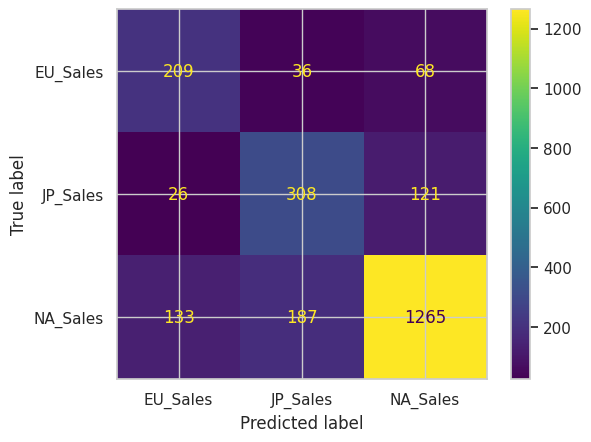

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# Início do experimento
mlflow.set_experiment("Experimento - Gradient Boosting")

with mlflow.start_run(run_name="Gradient Boosting - v1"):
    # Hiperparâmetros
    params = {
        'learning_rate': 0.05,
        'max_depth': 3,
        'min_samples_split': 2,
        'min_samples_leaf': 3,
        'n_estimators': 200,
        'subsample': 0.08,
        'max_features': None,
        'random_state': 42
    }

    modelo_gb = GradientBoostingClassifier(**params)

    # Class weights personalizados
    class_weight_person = {
        'NA_Sales': 1.0,
        'EU_Sales': 3.2,
        'JP_Sales': 2.8,
    }

    # Pesos para balanceamento
    sample_weights = compute_sample_weight(class_weight=class_weight_person, y=y_train)

    # Treinamento
    modelo_gb.fit(X_train, y_train, sample_weight=sample_weights)

    # Avaliação
    y_pred = modelo_gb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Validação cruzada
    scores = cross_val_score(modelo_gb, X, y, cv=5, scoring='accuracy')
    cv_acc = scores.mean()

    # Logging dos hiperparâmetros
    mlflow.log_params(params)

    # Logging das métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("cv_accuracy", cv_acc)
    mlflow.log_metric("precision_macro", report["macro avg"]["precision"])
    mlflow.log_metric("recall_macro", report["macro avg"]["recall"])
    mlflow.log_metric("f1_macro", report["macro avg"]["f1-score"])

    # Logging do modelo
    mlflow.sklearn.log_model(modelo_gb, "modelo_gradient_boosting")

    print("Acurácia:", acc)
    print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(modelo_gb, X_test, y_test)

- A confusão entre JP e NA faz sentido porquê jogos populares no Japão também fazem sucesso no Ocidente.

- A confusão entre Europa e NA é esperada por sobreposição de mercados.

# 8.3 Modelo k-Nearest Neighbors

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

mlflow.set_experiment("GridSearch KNN")

with mlflow.start_run(run_name="KNN GridSearch"):

    # Grid de hiperparâmetros
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
        'p': [1, 2]
    }

    knn = KNeighborsClassifier()

    grid_search = GridSearchCV(
        estimator=knn,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=2,
        scoring='accuracy'
    )

    # Treinamento
    grid_search.fit(X_train, y_train)

    best_knn = grid_search.best_estimator_

    y_pred = best_knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Log dos melhores hiperparâmetros
    for param, valor in grid_search.best_params_.items():
        mlflow.log_param(param, valor)

    # Log das métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision_weighted", report["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report["weighted avg"]["f1-score"])

    # Log do modelo
    mlflow.sklearn.log_model(best_knn, "knn_gridsearch_model")

    # Print resultados
    print("\n🔍 Melhores hiperparâmetros encontrados:")
    print(grid_search.best_params_)
    print("\n🔍 Acurácia após otimização:", acc)
    print("\n📋 Relatório de Classificação:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

2025/07/19 22:47:00 INFO mlflow.tracking.fluent: Experiment with name 'GridSearch KNN' does not exist. Creating a new experiment.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


2025/07/19 22:47:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:47:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🔍 Melhores hiperparâmetros encontrados:
{'metric': 'euclidean', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}

🔍 Acurácia após otimização: 0.7921801954951126

📋 Relatório de Classificação:

              precision    recall  f1-score   support

    EU_Sales       0.66      0.57      0.61       313
    JP_Sales       0.70      0.51      0.59       455
    NA_Sales       0.83      0.92      0.87      1585

    accuracy                           0.79      2353
   macro avg       0.73      0.66      0.69      2353
weighted avg       0.78      0.79      0.78      2353



# Modelo k-Nearest Neighbors com melhores hiperparâmetros

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import cross_val_score

with mlflow.start_run(run_name="Modelo KNN"):

    # Definir o modelo com hiperparâmetros
    knn = KNeighborsClassifier(
        metric='euclidean',
        n_neighbors=11,
        p=1,
        weights='uniform'
    )

    # Treinar o modelo
    knn.fit(X_train, y_train)

    # Previsões
    y_pred = knn.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)

    # Log de parâmetros
    mlflow.log_param("metric", 'euclidean')
    mlflow.log_param("n_neighbors", 11)
    mlflow.log_param("p", 1)
    mlflow.log_param("weights", 'uniform')

    # Log de métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("cv_mean_accuracy", cv_mean)
    mlflow.log_metric("precision_macro", report['macro avg']['precision'])
    mlflow.log_metric("recall_macro", report['macro avg']['recall'])
    mlflow.log_metric("f1_macro", report['macro avg']['f1-score'])

    # Log do modelo
    mlflow.sklearn.log_model(knn, "knn_model")

# Exibir os resultados
print("🔍 Acurácia:", acc)
print("\n📋 Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, zero_division=0))
print("CV Acurácia média:", cv_mean)

2025/07/19 22:47:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:47:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🔍 Acurácia: 0.7921801954951126

📋 Relatório de Classificação:

              precision    recall  f1-score   support

    EU_Sales       0.66      0.57      0.61       313
    JP_Sales       0.70      0.51      0.59       455
    NA_Sales       0.83      0.92      0.87      1585

    accuracy                           0.79      2353
   macro avg       0.73      0.66      0.69      2353
weighted avg       0.78      0.79      0.78      2353

CV Acurácia média: 0.7841727596265876


# 8.4 Modelo Support Vector Machine

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Dicionário com pesos personalizados para as classes
class_weight_person = {
    'NA_Sales': 1.0,
    'EU_Sales': 3.2,
    'JP_Sales': 2.8,
}

# Calcula os pesos de amostra para balanceamento
sample_weights = compute_sample_weight(class_weight=class_weight_person, y=y_train)

# Parâmetros do Grid Search
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

mlflow.set_experiment("GridSearch SVM com pesos")

with mlflow.start_run(run_name="SVM GridSearch Pesos"):

    # Configura o Grid Search com SVM
    grid_search = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )

    # Treina com pesos
    grid_search.fit(X_train, y_train, sample_weight=sample_weights)

    # Melhor modelo encontrado
    modelo_svm = grid_search.best_estimator_

    # Predição
    y_pred = modelo_svm.predict(X_test)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Log dos melhores parâmetros do Grid Search
    for param, valor in grid_search.best_params_.items():
        mlflow.log_param(param, valor)

    # Log das métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision_weighted", report["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report["weighted avg"]["f1-score"])

    # Log do modelo
    mlflow.sklearn.log_model(modelo_svm, "svm_gridsearch_pesos")

    # Exibe resultados
    print("Melhores parâmetros:", grid_search.best_params_)
    print("Acurácia:", acc)
    print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

2025/07/19 22:47:17 INFO mlflow.tracking.fluent: Experiment with name 'GridSearch SVM com pesos' does not exist. Creating a new experiment.


Fitting 3 folds for each of 12 candidates, totalling 36 fits


2025/07/19 22:53:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:53:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Melhores parâmetros: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Acurácia: 0.7518062048448789

Relatório de Classificação:
               precision    recall  f1-score   support

    EU_Sales       0.57      0.63      0.60       313
    JP_Sales       0.55      0.67      0.61       455
    NA_Sales       0.87      0.80      0.83      1585

    accuracy                           0.75      2353
   macro avg       0.66      0.70      0.68      2353
weighted avg       0.77      0.75      0.76      2353



# Modelo Support Vector Machine com otimização de hiperparâmetros

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Definindo hiperparâmetros
C = 10
kernel = 'rbf'
gamma = 'scale'
class_weight = 'balanced'
probability = True
random_state = 42

# Inicia experimento MLFlow
mlflow.set_experiment("Experimento - SVM")

with mlflow.start_run(run_name="SVM"):

    # Cria o modelo SVM
    clf = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        class_weight=class_weight,
        probability=probability,
        random_state=random_state
    )

    # Treina
    clf.fit(X_train, y_train)

    # Prediz
    y_pred = clf.predict(X_test)

    # Avalia
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    cv_mean = scores.mean()

    # Log parâmetros
    mlflow.log_param("C", C)
    mlflow.log_param("kernel", kernel)
    mlflow.log_param("gamma", gamma)
    mlflow.log_param("class_weight", class_weight)
    mlflow.log_param("probability", probability)

    # Log métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("cv_mean_accuracy", cv_mean)
    mlflow.log_metric("precision_weighted", report["weighted avg"]["precision"])
    mlflow.log_metric("recall_weighted", report["weighted avg"]["recall"])
    mlflow.log_metric("f1_weighted", report["weighted avg"]["f1-score"])

    # Log do modelo
    mlflow.sklearn.log_model(clf, "svm_model")

    # Imprime resultados
    print("🔍 Acurácia:", acc)
    print("\n📋 Relatório de Classificação:\n")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("✅ CV Acurácia média:", cv_mean)

2025/07/19 22:53:40 INFO mlflow.tracking.fluent: Experiment with name 'Experimento - SVM' does not exist. Creating a new experiment.
2025/07/19 22:56:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/19 22:56:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🔍 Acurácia: 0.42031449213769656

📋 Relatório de Classificação:

              precision    recall  f1-score   support

    EU_Sales       0.22      0.74      0.34       313
    JP_Sales       0.20      0.24      0.22       455
    NA_Sales       0.84      0.41      0.55      1585

    accuracy                           0.42      2353
   macro avg       0.42      0.46      0.37      2353
weighted avg       0.64      0.42      0.46      2353

✅ CV Acurácia média: 0.406917497130599


# 8.5 Modelo Multilayer Perceptron

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Hiperparâmetros a testar
param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam'],
    'max_iter': [300],
}

# MLP base
mlp_model = MLPClassifier(random_state=42)

# Random Search
random_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # Mais iter = melhor busca, mais tempo
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

# Treinar o random search
random_search.fit(X_train_mlp, y_train_mlp)

# Melhores parâmetros encontrados
print("Melhores hiperparâmetros:")
print(random_search.best_params_)

# Avaliação no conjunto de teste
best_model = random_search.best_estimator_
y_pred_mlp = best_model.predict(X_test_mlp)

print("\nAcurácia no conjunto de teste:", accuracy_score(y_test_mlp, y_pred_mlp))
print("\nRelatório de Classificação:")
print(classification_report(y_test_mlp, y_pred_mlp, target_names=le_top_region.classes_, zero_division=0))


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Melhores hiperparâmetros:
{'solver': 'adam', 'max_iter': 300, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'activation': 'tanh'}

Acurácia no conjunto de teste: 0.7672047578589635

Relatório de Classificação:
              precision    recall  f1-score   support

    EU_Sales       0.71      0.45      0.55       291
    JP_Sales       0.66      0.35      0.46       432
    NA_Sales       0.79      0.94      0.85      1629
 Other_Sales       0.00      0.00      0.00         2

    accuracy                           0.77      2354
   macro avg       0.54      0.43      0.47      2354
weighted avg       0.75      0.77      0.74      2354



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


# Modelo Multilayer Perceptron com melhores hiperparâmetros

In [12]:
# Modelo MLP com os melhores parâmetros
mlp_model = MLPClassifier(
    solver='adam',
    max_iter=300,
    learning_rate_init=0.001,
    hidden_layer_sizes=(128, 64),
    alpha=0.001,
    activation='tanh',
    random_state=42)


mlp_model.fit(X_train_mlp, y_train_mlp)

y_pred_mlp = mlp_model.predict(X_test_mlp)

print("Acurácia do melhor modelo:", accuracy_score(y_test_mlp, y_pred_mlp))
print("\nRelatório de Classificação:")
print(classification_report(y_test_mlp, y_pred_mlp, target_names=le_top_region.classes_, zero_division=0))

Acurácia do melhor modelo: 0.7672047578589635

Relatório de Classificação:
              precision    recall  f1-score   support

    EU_Sales       0.71      0.45      0.55       291
    JP_Sales       0.66      0.35      0.46       432
    NA_Sales       0.79      0.94      0.85      1629
 Other_Sales       0.00      0.00      0.00         2

    accuracy                           0.77      2354
   macro avg       0.54      0.43      0.47      2354
weighted avg       0.75      0.77      0.74      2354



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


# 9. Comparação final após otimização de hiperparâmetros

* Random Forest é o modelo mais eficaz após otimização, com a maior acurácia (0.80) e melhores métricas em NA_Sales e JP_Sales, além de um bom equilíbrio geral. Apresenta um avanço significativo comparado ao seu modelo anterior que conseguiu 70% de acurácia com muitos erros na análise das colunas.

* k-NN apresenta um desempenho intermediário (0.79), com destaque em precisão para JP Sales, mas menor recall geral. Também demonstrou um avanço significativo comparado aos erros cometidos nos testes anteriores.

* Gradient Boosting fica em último, com acurácia mais baixa (0.76) e desempenho menos consistente entre classes. Este último, por mais que tenha evoluído, continuou com problemas no aprendizado das colunas mesmo após otimização de hiperparâmetros, diferente dos modelos anteriores.



# 10.  Vizualização do MlFlow UI (Apenas teste - Google Colab).

In [14]:
from pyngrok import ngrok, conf
from google.colab import userdata
import os

# Pegando Secret interna do colab
AUTH_NGROK = userdata.get('AUTH_NGROK')

# Setando Secret como Env do colab
os.environ['AUTH_NGROK'] = AUTH_NGROK

# Setando token na conf do ngrok
conf.get_default().auth_token = AUTH_NGROK

# Encerrar conexões anteriores
ngrok.kill()

# Iniciar o MLflow UI (em segundo plano)
get_ipython().system_raw("mlflow ui --port 5000 &")

# Expor a porta 5000 do MLflow UI via ngrok
public_url = ngrok.connect(5000)
print(f"Acesse o MLflow UI aqui: {public_url}")

Acesse o MLflow UI aqui: NgrokTunnel: "https://d00dd8105880.ngrok-free.app" -> "http://localhost:5000"
